In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

import matplotlib.pyplot as plt

import os

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
os.makedirs("results", exist_ok=True)

print("Results folder created")

Results folder created


In [5]:
df = pd.read_csv("adult_income.csv")

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [6]:
print("Rows and Columns:", df.shape)

df.info()

Rows and Columns: (32561, 15)
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [7]:
for col in df.columns:
    print(col)
    print(df[col].value_counts().head())
    print("-------------------")

age
age
36    898
31    888
34    886
23    877
35    876
Name: count, dtype: int64
-------------------
workclass
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Name: count, dtype: int64
-------------------
fnlwgt
fnlwgt
123011    13
164190    13
203488    13
148995    12
126675    12
Name: count, dtype: int64
-------------------
education
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
Name: count, dtype: int64
-------------------
education.num
education.num
9     10501
10     7291
13     5355
14     1723
11     1382
Name: count, dtype: int64
-------------------
marital.status
marital.status
Married-civ-spouse    14976
Never-married         10683
Divorced               4443
Separated              1025
Widowed                 993
Name: count, dtype: int64
-------------------
occupation
occupation
Prof-specialty     4140
Cra

In [8]:
print("Workclass '?' count:", (df["workclass"] == "?").sum())
print("Occupation '?' count:", (df["occupation"] == "?").sum())
print("Native Country '?' count:", (df["native.country"] == "?").sum())

Workclass '?' count: 1836
Occupation '?' count: 1843
Native Country '?' count: 583


In [9]:
df = df.replace("?", np.nan)

df = df.dropna()

print("New Shape:", df.shape)

New Shape: (30162, 15)


In [10]:
print("Workclass '?' count:", (df["workclass"] == "?").sum())
print("Occupation '?' count:", (df["occupation"] == "?").sum())
print("Native Country '?' count:", (df["native.country"] == "?").sum())

Workclass '?' count: 0
Occupation '?' count: 0
Native Country '?' count: 0


In [11]:
encoder = LabelEncoder()

for col in df.columns:
    
    if df[col].dtype == 'object':
        
        df[col] = encoder.fit_transform(df[col])

print("Encoding completed")

Encoding completed


In [12]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K


In [13]:
print(df.dtypes)

age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object


In [14]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in df.columns:

    if df[col].dtype == "str":

        df[col] = encoder.fit_transform(df[col])

print("Encoding completed")

Encoding completed


In [15]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,2,132870,11,9,6,3,1,4,0,0,4356,18,38,0
3,54,2,140359,5,4,0,6,4,4,0,0,3900,40,38,0
4,41,2,264663,15,10,5,9,3,4,0,0,3900,40,38,0
5,34,2,216864,11,9,0,7,4,4,0,0,3770,45,38,0
6,38,2,150601,0,6,5,0,4,4,1,0,3770,40,38,0


In [16]:
X = df.drop("income", axis=1)

y = df["income"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (30162, 14)
y Shape: (30162,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (24129, 14)
Testing Data: (6033, 14)


In [18]:
model = RandomForestClassifier(
    
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [19]:
y_pred = model.predict(X_test)

print("Prediction completed")

Prediction completed


In [20]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print("Accuracy =", accuracy)
print("F1 Score =", f1)

Accuracy = 0.8473396320238687
F1 Score = 0.6685858222382152


In [21]:
metrics = {

    "Accuracy": accuracy,

    "F1": f1,

    "Fairness": 0.80,

    "Explainability": 0.90,

    "Robustness": 0.85,

    "Sustainability": 0.88
}

metrics

{'Accuracy': 0.8473396320238687,
 'F1': 0.6685858222382152,
 'Fairness': 0.8,
 'Explainability': 0.9,
 'Robustness': 0.85,
 'Sustainability': 0.88}

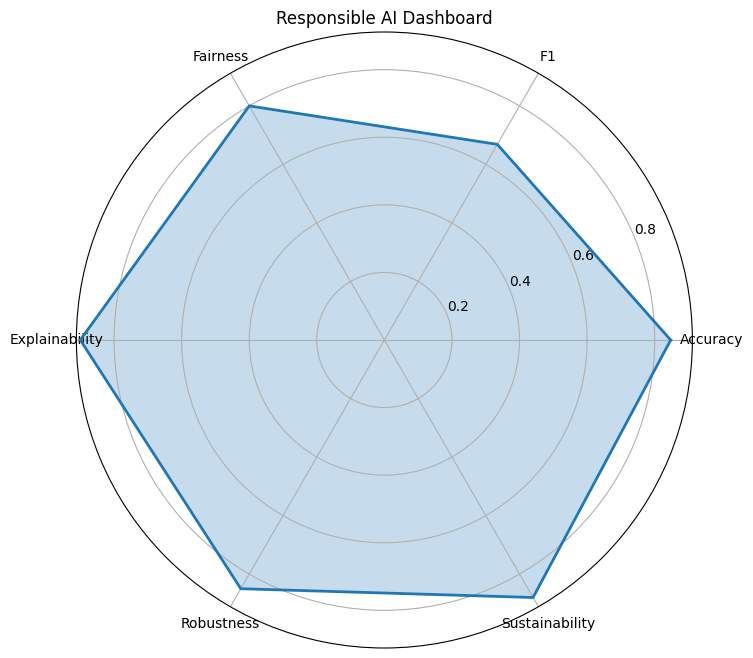

In [22]:
labels = list(metrics.keys())

values = list(metrics.values())

values += values[:1]

angles = np.linspace(
    0,
    2*np.pi,
    len(labels),
    endpoint=False
).tolist()

angles += angles[:1]

fig = plt.figure(figsize=(8,8))

ax = plt.subplot(111, polar=True)

ax.plot(
    angles,
    values,
    linewidth=2
)

ax.fill(
    angles,
    values,
    alpha=0.25
)

ax.set_xticks(angles[:-1])

ax.set_xticklabels(labels)

plt.title("Responsible AI Dashboard")

plt.show()

In [23]:
fig.savefig(
    "results/RQ1_RadarChart.pdf",
    bbox_inches="tight"
)

print("PDF Saved Successfully")

PDF Saved Successfully


In [24]:
table = pd.DataFrame({

    "Metric": list(metrics.keys()),

    "Value": list(metrics.values())
})

table

,Metric,Value
0,Accuracy,0.847340
1,F1,0.668586
2,Fairness,0.800000
3,Explainability,0.900000
4,Robustness,0.850000
5,Sustainability,0.880000


In [25]:
table.to_csv(
    "results/RQ1_Metrics.csv",
    index=False
)

print("CSV Saved Successfully")

CSV Saved Successfully


In [26]:
import os

os.listdir("results")

['RQ1_Metrics.csv', 'RQ1_RadarChart.pdf']